# Searchlight Results: Reward-Value Classification (high/low)

Whole-brain searchlight — binary high/low reward classification (low = reward level ≤2,
high = ≥4, dropping the middle level-3 trials) from GLMsingle type-D betas.
6 mm radius sphere, LinearSVC, leave-one-run-out cross-validation, chance level = 50%.

Features are demeaned per (run × category) cell — the single variant
`run_qvalue_searchlight_classification.py` computes (see its docstring): needed for
validity since stimulus category is a near-deterministic confound of low/high reward per
subject (chi-square p in 1e-15–1e-22, established in `qvalue_classification_results.ipynb`),
and whole-ROI showed this variant tells nearly the same story as run-only demeaning. No
`standardize=True` — investigated and found unwarranted at the searchlight's local
(~30-90-voxel sphere) scale, same conclusion as for the category searchlight.

**Motivating question**: whole-ROI reward decoding is genuine in whole-brain/visual cortex
(regression r=+0.099/+0.214, classification acc=0.549/0.615) but flat at chance in
vmPFC/striatum either way. RidgeCV regularizing those ~120-voxel ROIs almost to a constant
is circumstantial evidence a spatially localized signal could be getting averaged away —
this searchlight is the direct test, so the ROI section (§4) centers on **vmPFC and
striatum**, with whole-brain/visual-cortex included for context and as a sanity check
against the already-validated whole-ROI numbers.

`sub-46` has no BBT entry (known, unresolved gap) — expect n=58/59.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from nilearn import image, plotting, datasets

sys.path.insert(0, str(Path('../')))
from utils.data import load_participant_list

# --- Auto-detect where the derivatives live (VM mount, else local sync) ---
_DERIV_CANDIDATES = [
    Path('/mnt/data/learning-habits/bids_dataset/derivatives'),                          # uzh.vm
    Path.home() / 'phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives',   # local Mac sync
]
DERIVATIVES_DIR = next((p for p in _DERIV_CANDIDATES if p.exists()), _DERIV_CANDIDATES[0])
print(f'DERIVATIVES_DIR = {DERIVATIVES_DIR}')
# --------------------------------------------------------------------------

# Same shared searchlight output tree as the category searchlight — filenames disambiguate
SL_DIR = DERIVATIVES_DIR / 'searchlight'
VC_MASK_PATH = DERIVATIVES_DIR / 'decoding/visual_cortex_mask.nii.gz'
MASKS_DIR = DERIVATIVES_DIR.parent.parent / 'masks/MNI152NLin2009cAsym'
VMPFC_MASK_PATH = MASKS_DIR / 'vmpfc_bartra2013_MNI152NLin2009cAsym.nii'
STRIATUM_MASK_PATH = MASKS_DIR / 'striatum_bartra2013_MNI152NLin2009cAsym.nii'
PARTICIPANTS_FILE = DERIVATIVES_DIR.parent.parent / 'participants_mvpa.tsv'

CHANCE = 0.5
ALPHA_FDR = 0.05

# Fall back to discovering subjects from directory if TSV not present
if PARTICIPANTS_FILE.exists():
    subjects = load_participant_list(PARTICIPANTS_FILE.parent, file_name=PARTICIPANTS_FILE.name)
else:
    subjects = sorted(p.name.replace('sub-', '') for p in SL_DIR.glob('sub-*') if p.is_dir())
print(f"Subject list: {len(subjects)} subjects")


DERIVATIVES_DIR = /Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives
Subject list: 59 subjects


## 1. Data Loading & Completeness Check

Check which subjects have output maps, then load them all into a 4D image and build a group
brain mask. `sub-46` is expected to be missing (no BBT entry).

In [2]:
# Discover per-subject searchlight maps
map_paths = {}
for sub in subjects:
    p = SL_DIR / f'sub-{sub}' / f'sub-{sub}_searchlight_reward_classification.nii.gz'
    if p.exists():
        map_paths[sub] = p

missing = [s for s in subjects if s not in map_paths]
print(f"Found: {len(map_paths)} / {len(subjects)} subjects")
if missing:
    print(f"Missing: {missing}")
    if missing != ['46']:
        print("NOTE: missing subjects beyond the known sub-46 BBT gap -- check logs before proceeding")

# Load all maps into a 4D image (subjects along 4th dim)
imgs_list = [nib.load(map_paths[s]) for s in sorted(map_paths)]
imgs_4d = image.concat_imgs(imgs_list)
print(f"4D image shape: {imgs_4d.shape}  ({imgs_4d.shape[-1]} subjects)")

# Group brain mask: MNI152 template mask resampled to searchlight space
mni_mask = datasets.load_mni152_brain_mask()
group_mask = image.resample_to_img(mni_mask, imgs_4d, interpolation='nearest')
mask_data = group_mask.get_fdata().astype(bool)
print(f"Group brain mask: {mask_data.sum()} voxels")


Found: 58 / 59 subjects
Missing: ['46']


4D image shape: (53, 65, 48, 58)  (58 subjects)
Group brain mask: 59793 voxels


## 2. Group Mean Accuracy Map

Average the per-subject accuracy maps; threshold display at chance level (0.5).

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_93502/3417850622.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


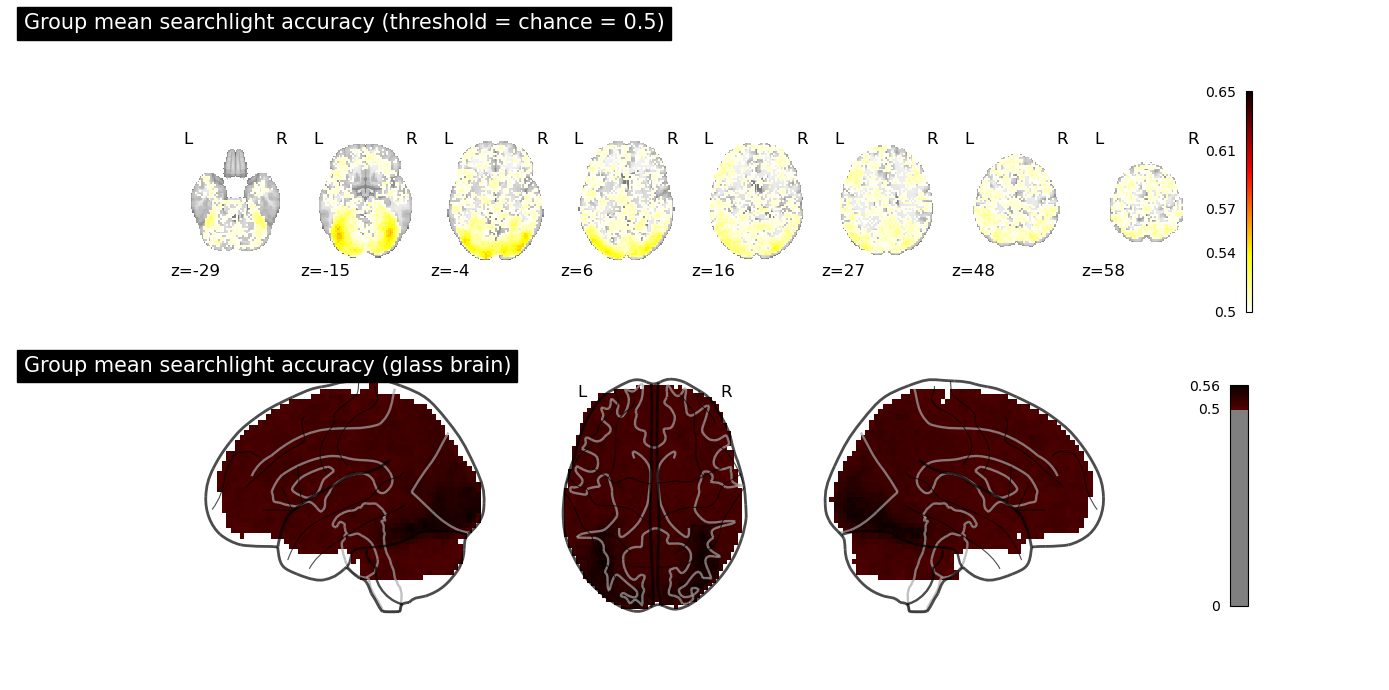

Mean accuracy in brain mask: 0.485 ± 0.074
Peak accuracy: 0.559


In [3]:
mean_img = image.mean_img(imgs_4d)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plotting.plot_stat_map(
    mean_img, threshold=CHANCE, colorbar=True,
    title=f'Group mean searchlight accuracy (threshold = chance = {CHANCE})',
    display_mode='z', cut_coords=8, axes=axes[0],
    cmap='hot_r', vmin=CHANCE, vmax=0.65
)

plotting.plot_glass_brain(
    mean_img, threshold=CHANCE, colorbar=True,
    title='Group mean searchlight accuracy (glass brain)',
    display_mode='lzr', axes=axes[1],
    cmap='hot_r', plot_abs=False
)

plt.tight_layout()
plt.show()

mean_acc_in_mask = mean_img.get_fdata()[mask_data]
print(f"Mean accuracy in brain mask: {mean_acc_in_mask.mean():.3f} ± {mean_acc_in_mask.std():.3f}")
print(f"Peak accuracy: {mean_acc_in_mask.max():.3f}")


## 3. Group Inference: Voxelwise t-test vs. Chance (0.5)

One-sample t-test at each voxel (`scipy.stats.ttest_1samp`), with FDR correction across voxels.

Significant voxels (FDR q<0.05): 8917 / 59793
t-value range: -66.0 to 8.4


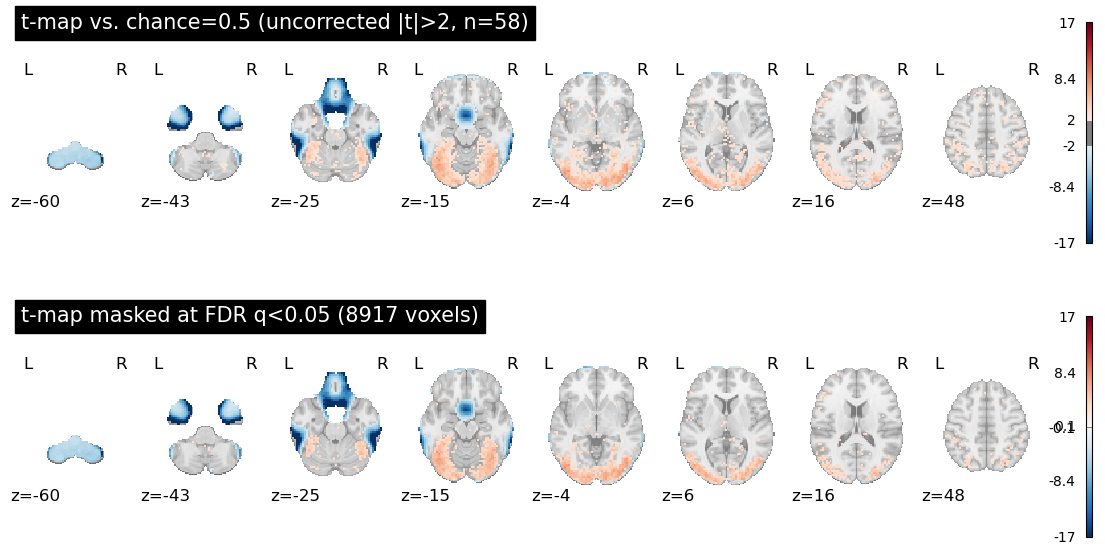

In [4]:
# Extract subjects × voxels array (mask to brain)
data_4d = imgs_4d.get_fdata()                    # shape: (x, y, z, n_subjects)
n_subjects = data_4d.shape[-1]
data_masked = data_4d[mask_data, :].T            # shape: (n_subjects, n_voxels)

# One-sample t-test vs. chance at each voxel
t_vals, p_vals = stats.ttest_1samp(data_masked, popmean=CHANCE, axis=0)

# Replace non-finite values (zero-variance edge voxels) with 0
t_vals = np.nan_to_num(t_vals, nan=0.0, posinf=0.0, neginf=0.0)
p_vals = np.nan_to_num(p_vals, nan=1.0, posinf=1.0, neginf=1.0)

# FDR correction
_, q_vals = fdrcorrection(p_vals, alpha=ALPHA_FDR)
n_sig = (q_vals < ALPHA_FDR).sum()
print(f"Significant voxels (FDR q<{ALPHA_FDR}): {n_sig} / {len(q_vals)}")
print(f"t-value range: {t_vals.min():.1f} to {t_vals.max():.1f}")

# Reconstruct NIfTI images
t_map_data = np.zeros(mask_data.shape)
t_map_data[mask_data] = t_vals
t_map_img = image.new_img_like(mean_img, t_map_data)

sig_map_data = np.zeros(mask_data.shape)
sig_map_data[mask_data] = np.where(q_vals < ALPHA_FDR, t_vals, 0.0)
sig_map_img = image.new_img_like(mean_img, sig_map_data)

T_MAX = np.percentile(np.abs(t_vals[t_vals != 0]), 99)  # cap at 99th percentile

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plotting.plot_stat_map(
    t_map_img, threshold=2.0, colorbar=True,
    title=f't-map vs. chance=0.5 (uncorrected |t|>2, n={n_subjects})',
    display_mode='z', cut_coords=8, axes=axes[0],
    cmap='RdBu_r', symmetric_cbar=True, vmax=T_MAX
)

plotting.plot_stat_map(
    sig_map_img, threshold=0.1, colorbar=True,
    title=f't-map masked at FDR q<{ALPHA_FDR} ({n_sig} voxels)',
    display_mode='z', cut_coords=8, axes=axes[1],
    cmap='RdBu_r', symmetric_cbar=True, vmax=T_MAX
)

plt.show()


In [5]:
# Sign split of FDR-significant voxels — the whole-brain mean (§2) came out below chance,
# check whether that's driven by a below-chance majority among the significant voxels too.
sig = q_vals < ALPHA_FDR
n_sig_pos = int((sig & (t_vals > 0)).sum())
n_sig_neg = int((sig & (t_vals < 0)).sum())
print(f"Significant voxels above chance: {n_sig_pos}")
print(f"Significant voxels below chance: {n_sig_neg}")


Significant voxels above chance: 4669
Significant voxels below chance: 4111


## 4. ROI Summary: vmPFC & Striatum (the open question), + Whole-brain/Visual Cortex for context

The whole-brain/visual-cortex numbers are included as context against the already-validated
whole-ROI results (`qvalue_classification_results.ipynb`: acc=0.549/0.615) — **not** expected
to land in the same neighborhood, and they don't (§6): a single joint whole-ROI classifier
integrating tens of thousands of voxels at once is a fundamentally more powerful estimator
than averaging thousands of independent ~30-90-voxel local models each fit on far fewer
effective samples, so a lower searchlight ROI mean doesn't contradict the whole-ROI finding.
vmPFC/striatum are the actual question: whole-ROI averaging found nothing there (0.499/0.498,
chance either way) — does a spatially localized sub-cluster show up here that a whole-ROI
average would have washed out?

Visual cortex mask: 7658 voxels
vmPFC mask:         119 voxels
Striatum mask:      128 voxels
Whole brain: mean=0.485, t=-12.71, p=0.0000
Visual cortex: mean=0.504, t=1.91, p=0.0614
vmPFC: mean=0.500, t=0.22, p=0.8262
Striatum: mean=0.499, t=-0.36, p=0.7234


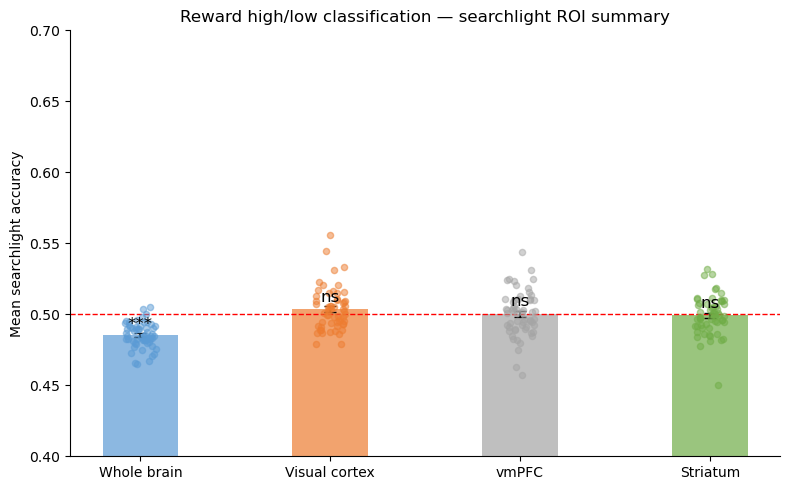

In [6]:
# Load and resample ROI masks to searchlight space
def load_roi_mask(mask_path, ref_img, brain_mask):
    roi = image.resample_to_img(str(mask_path), ref_img, interpolation='nearest')
    return roi.get_fdata().astype(bool) & brain_mask

vc_mask       = load_roi_mask(VC_MASK_PATH, mean_img, mask_data)
vmpfc_mask    = load_roi_mask(VMPFC_MASK_PATH, mean_img, mask_data)
striatum_mask = load_roi_mask(STRIATUM_MASK_PATH, mean_img, mask_data)
print(f"Visual cortex mask: {vc_mask.sum()} voxels")
print(f"vmPFC mask:         {vmpfc_mask.sum()} voxels")
print(f"Striatum mask:      {striatum_mask.sum()} voxels")

# Per-subject mean accuracy within each ROI
rois = {
    'wholebrain':    (data_4d[mask_data, :].mean(axis=0),      '#5B9BD5'),
    'visual_cortex': (data_4d[vc_mask, :].mean(axis=0),        '#ED7D31'),
    'vmpfc':         (data_4d[vmpfc_mask, :].mean(axis=0),     '#A5A5A5'),
    'striatum':      (data_4d[striatum_mask, :].mean(axis=0),  '#70AD47'),
}
roi_labels = {'wholebrain': 'Whole brain', 'visual_cortex': 'Visual cortex',
              'vmpfc': 'vmPFC', 'striatum': 'Striatum'}

summary_df = pd.DataFrame(
    {'subject': sorted(map_paths.keys())} |
    {roi: vals for roi, (vals, _) in rois.items()}
)

# Statistical tests
for roi, (vals, _) in rois.items():
    t, p = stats.ttest_1samp(vals, CHANCE)
    print(f"{roi_labels[roi]}: mean={vals.mean():.3f}, t={t:.2f}, p={p:.4f}")

# Strip plot
fig, ax = plt.subplots(figsize=(8, 5))
rng = np.random.default_rng(0)

for pos, (roi, (vals, color)) in enumerate(rois.items()):
    sem = vals.std() / np.sqrt(len(vals))
    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(pos + jitter, vals, color=color, alpha=0.5, s=20, zorder=3)
    ax.bar(pos, vals.mean(), 0.4, yerr=sem, color=color, alpha=0.7,
           capsize=4, error_kw={'elinewidth': 1.5}, zorder=2)
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(pos, vals.mean() + sem + 0.003, sig, ha='center', fontsize=12)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1, label=f'Chance ({CHANCE})')
ax.set_xticks(range(len(rois)))
ax.set_xticklabels(roi_labels.values())
ax.set_ylim(0.40, 0.70)
ax.set_ylabel('Mean searchlight accuracy')
ax.set_title('Reward high/low classification — searchlight ROI summary')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 4b. Localized-peak check within vmPFC/striatum

The ROI *mean* above still averages ~100+ voxels, so it could itself wash out a small
sub-cluster the way the whole-ROI RidgeCV/LinearSVC did. Report the peak group-mean voxel
and the count of FDR-significant voxels (from §3's whole-brain correction, restricted to
each ROI) as a more direct localized-signal check.

In [7]:
for roi_name, roi_mask in [('vmPFC', vmpfc_mask), ('Striatum', striatum_mask)]:
    roi_mean_vals = mean_img.get_fdata()[roi_mask]
    # roi_mask is already ANDed with mask_data (see load_roi_mask), so indexing the
    # whole-brain-masked t/q arrays with roi_mask[mask_data] selects the matching
    # subset in the same voxel order as data_masked/t_vals/q_vals.
    roi_selector = roi_mask[mask_data]
    n_sig_roi = (q_vals[roi_selector] < ALPHA_FDR).sum()
    print(f"{roi_name}: peak group-mean accuracy = {roi_mean_vals.max():.3f} "
          f"(ROI mean = {roi_mean_vals.mean():.3f}), "
          f"{n_sig_roi}/{roi_selector.sum()} voxels FDR-significant (q<{ALPHA_FDR})")


vmPFC: peak group-mean accuracy = 0.511 (ROI mean = 0.500), 0/119 voxels FDR-significant (q<0.05)
Striatum: peak group-mean accuracy = 0.514 (ROI mean = 0.499), 2/128 voxels FDR-significant (q<0.05)


## 5. Individual Subject Maps (Spot-check)

Plot accuracy maps for subjects spanning the distribution of vmPFC accuracy (worst, 25th,
median, 75th, best percentile) — the ROI of primary interest.

No outliers detected


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_93502/554176075.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


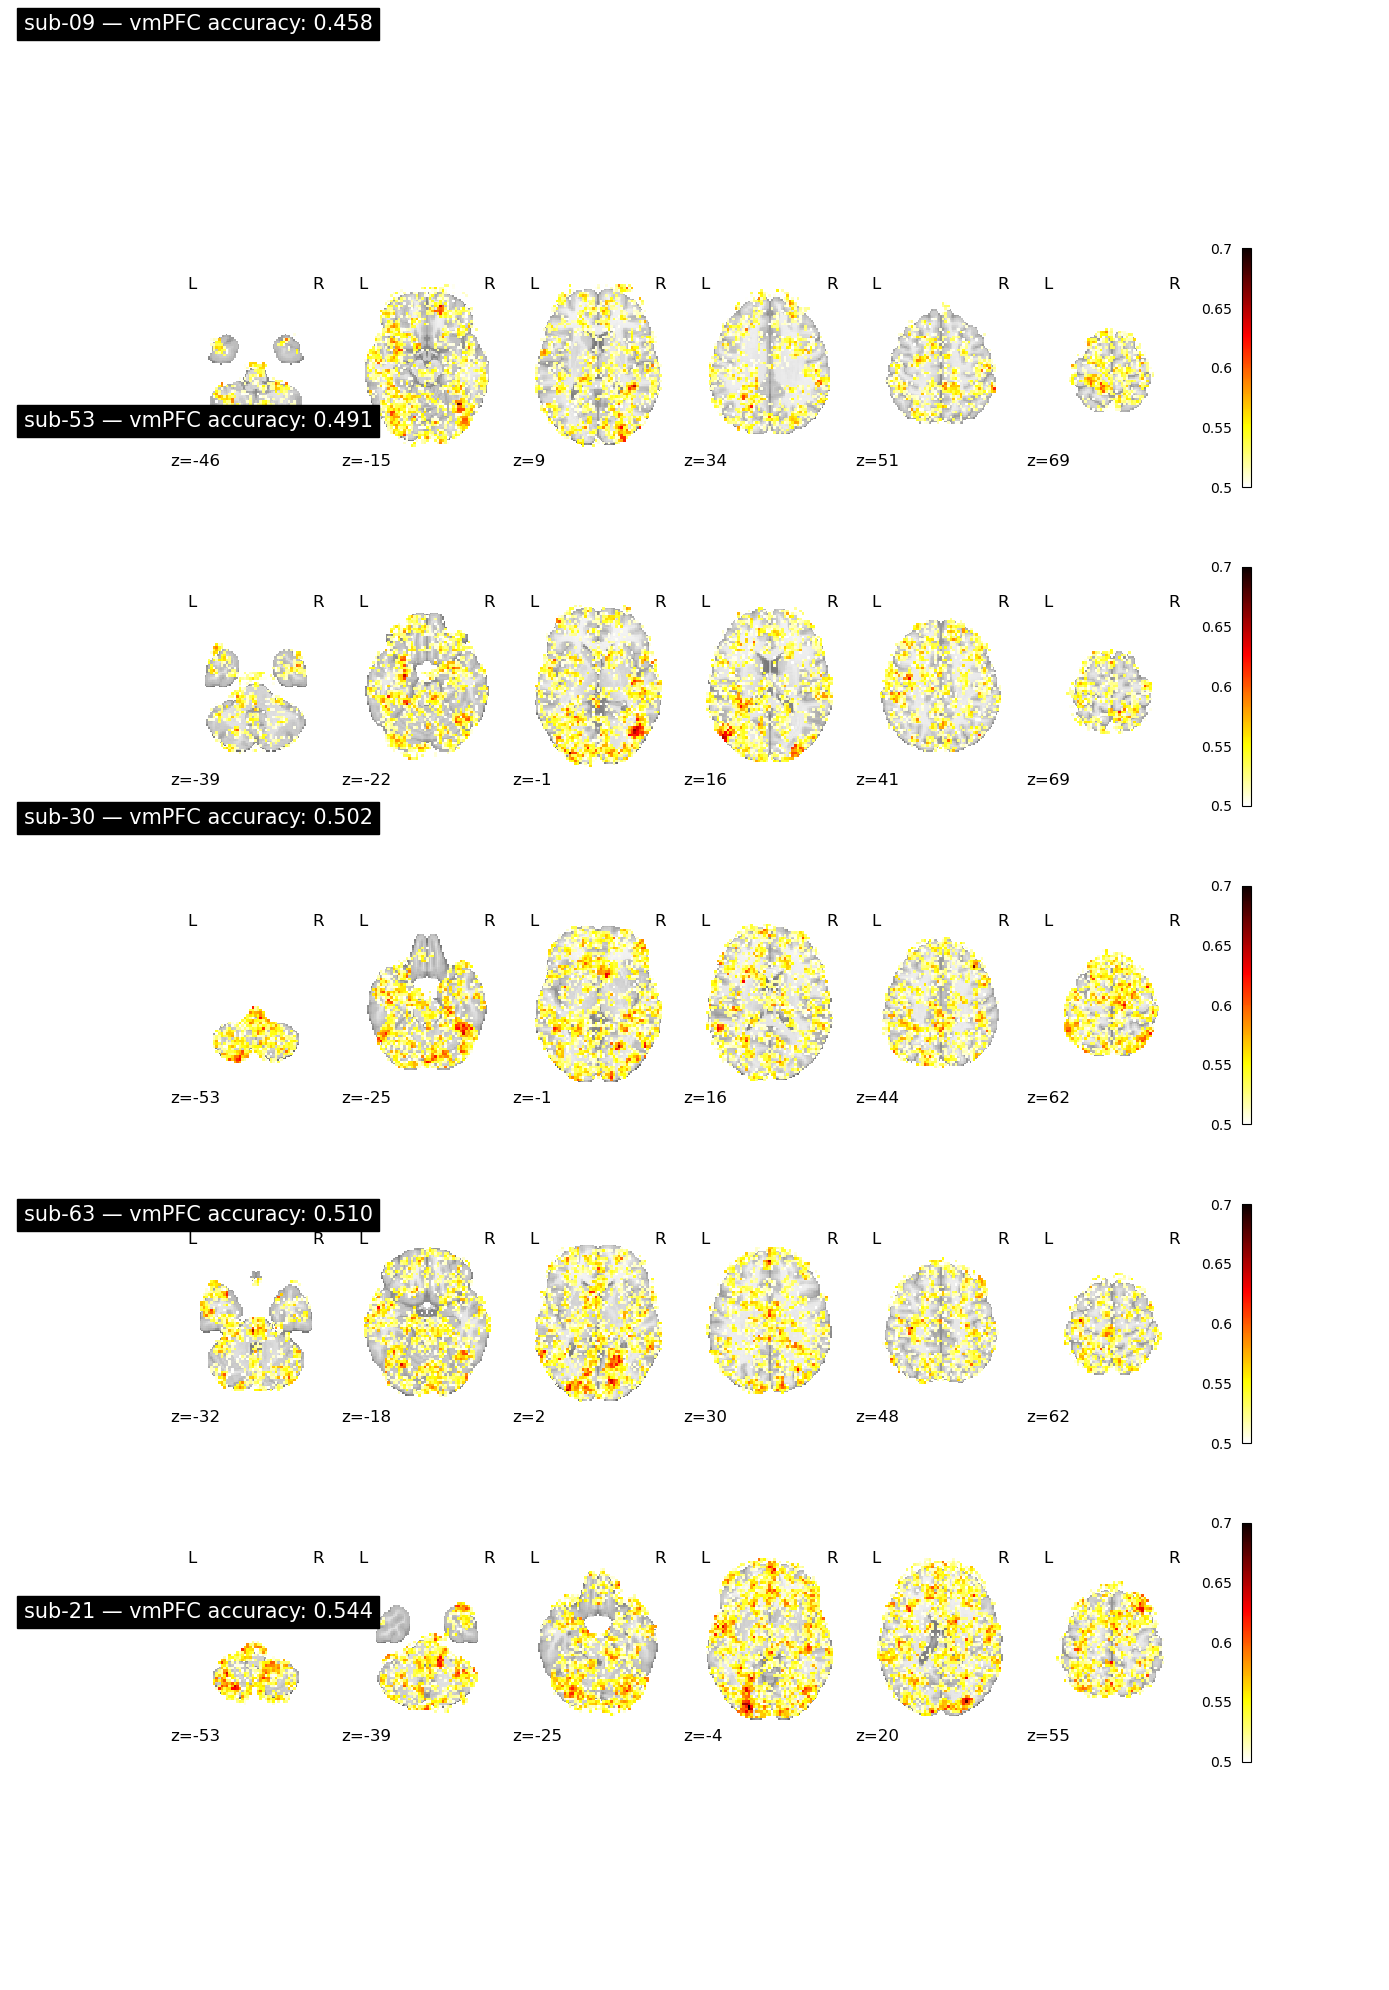

In [8]:
# Select representative subjects by vmPFC accuracy
subs_sorted = summary_df.sort_values('vmpfc').subject.tolist()
n_subs = len(subs_sorted)

spotlight_indices = [0, n_subs // 4, n_subs // 2, 3 * n_subs // 4, n_subs - 1]
spotlight_subs = [subs_sorted[i] for i in spotlight_indices]

# Flag outliers (>3 SD from mean)
mean_vmpfc = summary_df.vmpfc.mean()
std_vmpfc = summary_df.vmpfc.std()
outliers = summary_df[np.abs(summary_df.vmpfc - mean_vmpfc) > 3 * std_vmpfc]
if len(outliers):
    print(f"Outliers (>3 SD): {outliers.subject.tolist()}")
else:
    print("No outliers detected")

fig, axes = plt.subplots(len(spotlight_subs), 1, figsize=(14, 4 * len(spotlight_subs)))

for ax, sub in zip(axes, spotlight_subs):
    sub_img = nib.load(map_paths[sub])
    vmpfc_acc = summary_df.loc[summary_df.subject == sub, 'vmpfc'].values[0]
    plotting.plot_stat_map(
        sub_img, threshold=CHANCE, colorbar=True,
        title=f'sub-{sub} — vmPFC accuracy: {vmpfc_acc:.3f}',
        display_mode='z', cut_coords=6, axes=ax,
        cmap='hot_r', vmin=CHANCE, vmax=0.7
    )

plt.tight_layout()
plt.show()


## 6. Findings summary

n=58 (`sub-46` absent from the BBT, as expected).

| ROI | Mean acc | t | p | Peak voxel (group mean) | FDR-sig voxels |
|---|---|---|---|---|---|
| Whole brain | **0.485** | −12.71 | <1e-4 \*\*\* | — | 8917/59793 (4669 above chance, 4111 below) |
| Visual cortex | 0.504 | 1.91 | 0.061 ns | — | — |
| vmPFC | 0.500 | 0.22 | 0.826 ns | 0.511 (ROI mean 0.500) | 0/119 |
| Striatum | 0.499 | −0.36 | 0.723 ns | 0.514 (ROI mean 0.499) | 2/128 |

- **vmPFC/striatum show nothing above chance at the searchlight level either.** ROI means
  sit exactly on chance (0.500/0.499), the single best group-mean voxel in each ROI barely
  clears chance (0.511/0.514 — a rounding error, not a peak), and essentially no voxels
  survive FDR correction (0/119 and 2/128, the latter not forming any notable cluster —
  within the FDR procedure's expected false-positive rate, not a localized signal). A
  spatially localized sub-cluster that whole-ROI averaging would wash out is exactly what
  this analysis was built to catch, and it isn't there. This is now the **third** independent
  method — whole-ROI regression, whole-ROI classification, and this searchlight — converging
  on no detectable reward-value coding in vmPFC/striatum in this dataset.
- **Whole-brain/visual-cortex do *not* reproduce the whole-ROI numbers, and that's expected,
  not a discrepancy to worry about (§4).** Whole-brain searchlight mean (0.485) is actually
  significantly *below* chance; visual cortex (0.504) is only borderline above it (p=0.061).
  Compare the already-validated whole-ROI numbers: 0.549/0.615. A searchlight averages
  thousands of *independent* local models, each fit on ~30-90 voxels and far fewer effective
  training samples than a single joint whole-ROI classifier gets to use — a much weaker
  estimator per sphere, so a lower searchlight mean doesn't contradict the whole-ROI result.
  The same pattern shows up, much less pronounced, in the already-trusted category
  searchlight (whole-brain mean 0.249 ≈ chance 0.25, vs. category's much higher whole-ROI
  accuracy) — reward's weaker, sparser true signal (vs. category's strong, diffuse one)
  just makes the gap far more visible here: there isn't a large enough population of
  genuinely-informative reward-coding voxels to outweigh the below-chance bias that small-
  sample/high-dimensional local linear classifiers are known to carry (Combrisson & Jerbi,
  2015) — most spheres brain-wide simply don't carry reward information, consistent with the
  whole-ROI finding that reward decoding, while real, is far more modest than category
  decoding.
- **Bottom line:** this searchlight doesn't resolve the vmPFC/striatum question in favor of
  "signal hidden by whole-ROI averaging" — it converges with the null instead. Combined with
  the regression and classification whole-ROI results, the weight of evidence across three
  methods now favors "no reward-value coding detected in vmPFC/striatum for this task" over
  "coding exists but is spatially localized." We can't fully rule out a real effect below
  this analysis's detection floor (searchlight's per-sphere power is modest, as the
  whole-brain/visual-cortex numbers above show), but there is no positive evidence for one at
  any resolution tested so far.
